In [ ]:
!hostname

node107


In [1]:
import pickle as pkl
import pandas as pd
import numpy as np
from pathlib import Path

%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

## Get participant data for current pipeline

In [2]:
rel_result_path = '/mindhive/mcdermott/www/imgriff/part_data/binaural_cocktail_party/pilot_rel_dist_elev_v01/'
results = sorted(list(Path(rel_result_path).glob('*.json')))
# results += rel_results
# manifests += rel_manifests

results



[PosixPath('/mindhive/mcdermott/www/imgriff/part_data/binaural_cocktail_party/pilot_rel_dist_elev_v01/participant_001.json'),
 PosixPath('/mindhive/mcdermott/www/imgriff/part_data/binaural_cocktail_party/pilot_rel_dist_elev_v01/participant_002.json')]

In [3]:
# read results into pandas from json 
pd.read_json(results[0]).T

,trial_num,locations,response
0,1,"[[-30, 40], [-30, 30]]",e7
1,2,"[[-90, -20], [-90, 10]]",
2,3,"[[0, 0], [0, 10]]",g1e10
3,4,"[[30, 30], [30, 0]]",d13
4,5,"[[-30, 20], [-30, 0]]",d7
...,...,...,...
445,446,"[[90, -20], [90, -10]]",g19
446,447,"[[30, 40], [30, 10]]",b13
447,448,"[[90, 10], [90, 40]]",a19
448,449,"[[0, 0], [0, 30]]",e10


In [4]:
import string 
### Get map from speaker name to location and vice versa
name2loc = {}
loc2name = {}
num_azimuths = 19 # number of columns in speaker array
num_elevations = 7 # number of rows in speaker array
degree_spacing = 10 # spacing between speakers in degrees
max_elevation = 40 
max_azimuth = 90    
alphabet = string.ascii_uppercase[:num_elevations] # letter labels for speaker rows
for elev_ind in range(num_elevations):
    elev = max_elevation - degree_spacing * elev_ind # convert index into elevation degrees
    row = alphabet[elev_ind] # get row name
    for azim_ind in range(num_azimuths):
        azim = degree_spacing * azim_ind - max_azimuth # convert index into azimuth degrees
        col = azim_ind + 1 # get column name
        name = f'{row}{col}'.lower() # get name of speaker for given azimuth and elevation
        name2loc[name] = (azim, elev)
        loc2name[(azim, elev)] = name


In [5]:
## Get all participant data into one df for analysis
def get_part_df(fname):
    part_df = pd.read_json(fname).T
    part_df['participant'] = fname.stem
    # unbox locations 
    part_df['target_azim'] = part_df['locations'].apply(lambda x: x[0][0])
    part_df['target_elev'] = part_df['locations'].apply(lambda x: x[0][1])
    part_df['distractor_azim'] = part_df['locations'].apply(lambda x: x[1][0])
    part_df['distractor_elev'] = part_df['locations'].apply(lambda x: x[1][1])
    part_df.trial_num = part_df.trial_num.astype(float).astype('int')
    part_df['target_loc'] = part_df['locations'].apply(lambda x: loc2name[(x[0][0], x[0][1])])
    part_df['distractor_loc'] = part_df['locations'].apply(lambda x: loc2name[(x[1][0], x[1][1])])
    part_df['response_loc'] = part_df['response'].map(name2loc)
    
    # part_df['response_elev'] = part_df['response'].apply(lambda x: name2loc[x][1])
    return part_df

results_df = pd.concat([get_part_df(fname) for fname in results], axis=0, ignore_index=True)    
results_df.drop(columns=['pres_num'], inplace=True)

In [6]:
#split string where letter comes after number 
results_df.loc[1, 'response'] = 'g1'
results_df.loc[2, 'response'] = 'e10'

# remap 
locs = results_df['response'].map(name2loc).values
locs = np.vstack([loc if isinstance(loc, tuple) else (loc, loc) for loc in locs])
results_df['response_azim'] = locs[:, 0].astype('int')
results_df['response_elev'] = locs[:, 1].astype('int')

# drop trials with missing response
results_df = results_df[results_df.response.isin(name2loc.keys())].reset_index(drop=True)


In [9]:
# get scoring 

results_df['correct'] = (results_df['response'] == results_df['target_loc']).astype('int')
results_df['confusion'] = (results_df['response'] == results_df['distractor_loc']).astype('int')
results_df['azim_error'] = np.abs(results_df['response_azim'] - results_df['target_azim'])
results_df['elev_error'] = np.abs(results_df['response_elev'] - results_df['target_elev'])
results_df['distractor_elev_delta'] = np.abs(results_df['distractor_elev'] - results_df['target_elev'])

In [10]:
results_df.head()

,trial_num,locations,response,participant,target_azim,target_elev,distractor_azim,distractor_elev,target_loc,distractor_loc,response_loc,response_azim,response_elev,correct,confusion,azim_error,elev_error,distractor_elev_delta
0,1,"[[-30, 40], [-30, 30]]",e7,participant_001,-30,40,-30,30,a7,b7,"(-30, 0)",-30,0,0,0,0,40,10
1,2,"[[-90, -20], [-90, 10]]",g1,participant_001,-90,-20,-90,10,g1,d1,NaN,-90,-20,1,0,0,0,30
2,3,"[[0, 0], [0, 10]]",e10,participant_001,0,0,0,10,e10,d10,NaN,0,0,1,0,0,0,10
3,4,"[[30, 30], [30, 0]]",d13,participant_001,30,30,30,0,b13,e13,"(30, 10)",30,10,0,0,0,20,30
4,5,"[[-30, 20], [-30, 0]]",d7,participant_001,-30,20,-30,0,c7,e7,"(-30, 10)",-30,10,0,0,0,10,20


## Accuracy by azimuth (0 degree elevation)

In [18]:
results_df.groupby('participant').correct.mean()

participant
participant_001    0.450893
participant_002    0.476615
Name: correct, dtype: float64

In [13]:
grouped_results = results_df.groupby(['target_azim', 'target_elev', 'participant', "distractor_elev_delta"
                                      ]).agg({'correct':['mean', 'sem'],
                                                            'confusion':['mean', 'sem'],
                                                            'azim_error':['mean', 'sem'],
                                                            'elev_error':['mean', 'sem'],
                                                            'response_elev': ['mean', 'sem']
                                                            }).reset_index()
# flatten multiindex
grouped_results.columns = ['_'.join(col).strip() for col in grouped_results.columns.values]
grouped_results.columns = [col[:-1] if col[-1] == '_' else col for col in grouped_results.columns.values]



In [14]:

grouped_results.elev_error_mean.max()

30.0

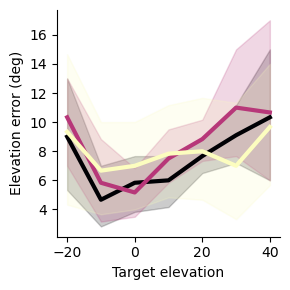

In [16]:
# sns.set_theme(style="ticks")

g = sns.relplot(data=grouped_results,
            x="target_elev", y="elev_error_mean", hue='distractor_elev_delta', #col='distractor_elev',
            kind="line", palette="magma", linewidth=3, zorder=5,
            height=3, aspect=1, legend=False,
        )
# g.set_titles("target e {col_name}", fontweight="bold")
# g.set(xticks=np.arange(-90, 91, 30), yticks=np.arange(0., 1.1, 0.2))
g.set_axis_labels("Target elevation", "Elevation error (deg)")




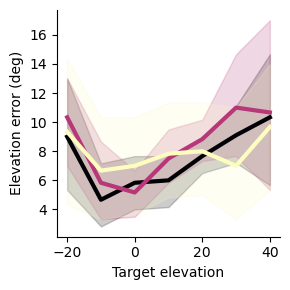

In [17]:
# sns.set_theme(style="ticks")

g = sns.relplot(data=grouped_results,
            x="target_elev", y="elev_error_mean", hue='distractor_elev_delta', #col='distractor_elev',
            kind="line", palette="magma", linewidth=3, zorder=5,
            height=3, aspect=1, legend=False,
        )
# g.set_titles("target e {col_name}", fontweight="bold")
# g.set(xticks=np.arange(-90, 91, 30), yticks=np.arange(0., 1.1, 0.2))
g.set_axis_labels("Target elevation", "Elevation error (deg)")




In [78]:
grouped_results

,target_elev,participant,correct_mean,confusion_mean,elev_error_mean,response_elev_mean
0,-20,participant_001,0.488889,0.177778,8.888889,-11.111111
1,-20,participant_002,0.511111,0.177778,10.222222,-9.777778
2,-10,participant_001,0.650000,0.166667,4.833333,-6.500000
3,-10,participant_002,0.610169,0.067797,6.101695,-6.271186
4,0,participant_001,0.653333,0.080000,3.866667,-0.400000
5,0,participant_002,0.453333,0.173333,7.733333,3.466667
6,10,participant_001,0.455556,0.111111,6.555556,7.666667
7,10,participant_002,0.411111,0.111111,7.666667,13.888889
8,20,participant_001,0.346667,0.160000,8.266667,13.600000
9,20,participant_002,0.386667,0.173333,8.133333,20.400000


Index(['target_elev', 'distractor_elev_delta', 'response_elev_mean_mean',
       'response_elev_mean_sem'],
      dtype='object')
[-20 -10   0  10  20  30  40]


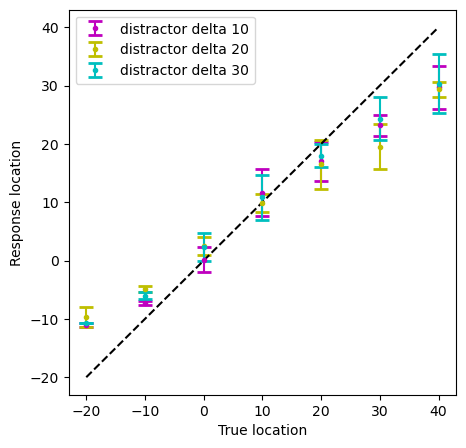

In [27]:
## Plot true vs predicted elevation 
grouped_results = results_df.groupby(['target_elev', 'participant', 'distractor_elev_delta'
                                      ]).agg({'correct':['mean'],
                                            'confusion':['mean'],
                                            'elev_error':['mean'],
                                            'response_elev': ['mean']
                                            }).reset_index()
grouped_results.columns = ['_'.join(col).strip() for col in grouped_results.columns.values]
grouped_results.columns = [col[:-1] if col[-1] == '_' else col for col in grouped_results.columns.values]

grouped_results = grouped_results.groupby(['target_elev',  'distractor_elev_delta']
                                    ).agg({'response_elev_mean':['mean', 'sem'],
                                          }).reset_index()
grouped_results.columns = ['_'.join(col).strip() for col in grouped_results.columns.values]
grouped_results.columns = [col[:-1] if col[-1] == '_' else col for col in grouped_results.columns.values]
print(grouped_results.columns)
# flatten multiindex

print(grouped_results.target_elev.unique())
# sns.set_theme(style="ticks")
plt.figure(figsize=(5, 5))

colors = ['c', 'y','m']
for delta in grouped_results.distractor_elev_delta.unique():
    subset = grouped_results[grouped_results.distractor_elev_delta == delta]
    plt.errorbar(subset.target_elev, subset.response_elev_mean_mean, yerr=subset.response_elev_mean_sem, fmt='.', capsize=5, capthick=2, label=f"distractor delta {delta}", color=colors.pop())

x_ticks = np.arange(-20, 41, 10)
# x_vals = grouped_results['target_elev'].values
# y_vals = grouped_results['response_elev_mean_mean'].values
# y_err = grouped_results['response_elev_mean_sem'].values

plt.plot(x_ticks, x_ticks, 'k--')
# plt.errorbar(x_vals, y_vals, yerr=y_err, fmt='.', capsize=5, capthick=2)
# add x = y line 
plt.xlabel('True location')
plt.ylabel('Response location')
# plt.xlim(-20,41)
# plt.ylim(-20,41)
plt.legend()
# g.set_titles("target e {col_name}", fontweight="bold")

# g.set(xticks=np.arange(-20, 41, 10), yticks=np.arange(-20, 41, 10));
# g.set_axis_labels("True elevation", "Response elevation")






Index(['target_elev', 'response_elev_mean_mean', 'response_elev_mean_sem'], dtype='object')
[-20 -10   0  10  20  30  40]


Text(0, 0.5, 'Response location')

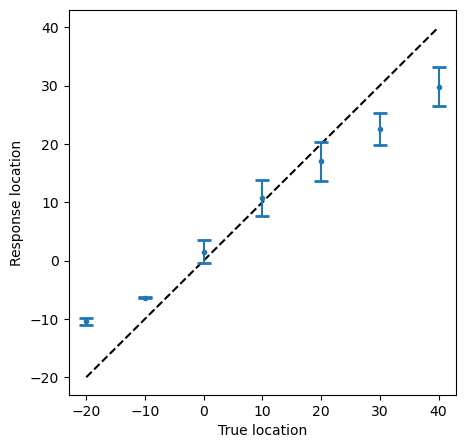

In [28]:
## Plot true vs predicted elevation 
grouped_results = results_df.groupby(['target_elev', 'participant',
                                      ]).agg({'correct':['mean'],
                                            'confusion':['mean'],
                                            'elev_error':['mean'],
                                            'response_elev': ['mean']
                                            }).reset_index()
grouped_results.columns = ['_'.join(col).strip() for col in grouped_results.columns.values]
grouped_results.columns = [col[:-1] if col[-1] == '_' else col for col in grouped_results.columns.values]

grouped_results = grouped_results.groupby('target_elev'
                                    ).agg({'response_elev_mean':['mean', 'sem'],
                                          }).reset_index()
grouped_results.columns = ['_'.join(col).strip() for col in grouped_results.columns.values]
grouped_results.columns = [col[:-1] if col[-1] == '_' else col for col in grouped_results.columns.values]
print(grouped_results.columns)
# flatten multiindex

print(grouped_results.target_elev.unique())
# sns.set_theme(style="ticks")
plt.figure(figsize=(5, 5))

x_ticks = np.arange(-20, 41, 10)
x_vals = grouped_results['target_elev'].values
y_vals = grouped_results['response_elev_mean_mean'].values
y_err = grouped_results['response_elev_mean_sem'].values

plt.plot(x_vals, x_vals, 'k--')
plt.errorbar(x_vals, y_vals, yerr=y_err, fmt='.', capsize=5, capthick=2)
# add x = y line 
plt.xlabel('True location')
plt.ylabel('Response location')
# plt.xlim(-20,41)
# plt.ylim(-20,41)

# g.set_titles("target e {col_name}", fontweight="bold")

# g.set(xticks=np.arange(-20, 41, 10), yticks=np.arange(-20, 41, 10));
# g.set_axis_labels("True elevation", "Response elevation")






array([[-11.11111111,  -9.77777778],
       [ -6.5       ,  -6.27118644],
       [ -0.4       ,   3.46666667],
       [  7.66666667,  13.88888889],
       [ 13.6       ,  20.4       ],
       [ 19.82758621,  25.33333333],
       [ 26.44444444,  33.11111111]])